# Notebook 03 - CARMA QMLE and 2024 Levy driver fit

This notebook uses the CARMA coefficients exported by notebook 02, estimates the
Gaussian prediction-error QMLE on 2024, and recovers the 2024 Levy driver increments.

The split is explicit:

- 2024 is the calibration sample for QMLE;
- 2025 is kept out of the parameter estimation and is used only for validation diagnostics.

The recovered 2024 driver increments are fitted with Gaussian and NIG laws. The 2025
sample is not used for these fits; it is kept for the next validation and forecasting
phase.


In [1]:
%matplotlib inline

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.linalg import expm, solve_continuous_lyapunov
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import minimize
from scipy.special import kve
from scipy.stats import norm, norminvgauss

plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

CWD = Path.cwd().resolve()
if (CWD / "france" / "france24vs25" / "data" / "seasonality" / "price_panel_2024_train.csv").exists():
    PROJECT_ROOT = CWD
    CHECK_DIR = CWD / "france" / "france24vs25"
elif (CWD / "data" / "seasonality" / "price_panel_2024_train.csv").exists():
    CHECK_DIR = CWD
    PROJECT_ROOT = CWD.parent.parent
else:
    raise FileNotFoundError("Run this notebook from the repo root or from france/france24vs25/. Run notebook 01 first.")

DATA = CHECK_DIR / "data"
SEAS = DATA / "seasonality"
OUT = DATA / "kalman"
FIG = CHECK_DIR / "figures"
OUT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(parents=True, exist_ok=True)

TRAIN_PANEL = SEAS / "price_panel_2024_train.csv"
TEST_PANEL = SEAS / "price_panel_2025_test.csv"
REQUIRED_COLS = ["price_raw", "log_price", "log_price_seasonal", "log_price_resid"]


def load_panel(path, expected_year, split_label):
    panel = pd.read_csv(path, index_col=0, parse_dates=True)
    missing = [c for c in REQUIRED_COLS if c not in panel.columns]
    if missing:
        raise ValueError(f"{path} is missing required columns: {missing}")
    panel = panel.dropna(subset=REQUIRED_COLS)
    panel = panel[np.isfinite(panel[REQUIRED_COLS]).all(axis=1)].copy()
    if not (panel.index.year == expected_year).all():
        years = sorted(panel.index.year.unique())
        raise ValueError(f"{path} should contain only {expected_year}; found {years}")
    panel["split"] = split_label
    return panel


panel_train = load_panel(TRAIN_PANEL, 2024, "train_2024")
panel_test = load_panel(TEST_PANEL, 2025, "test_2025")
panel_all = pd.concat([panel_train, panel_test], axis=0)

price_train = panel_train["price_raw"].to_numpy(float)
log_price_train = panel_train["log_price"].to_numpy(float)
seasonal_train = panel_train["log_price_seasonal"].to_numpy(float)
y_train = panel_train["log_price_resid"].to_numpy(float)

price_test = panel_test["price_raw"].to_numpy(float)
log_price_test = panel_test["log_price"].to_numpy(float)
seasonal_test = panel_test["log_price_seasonal"].to_numpy(float)
y_test = panel_test["log_price_resid"].to_numpy(float)

price_shift = float(np.median(np.exp(panel_all["log_price"].to_numpy(float)) - panel_all["price_raw"].to_numpy(float)))
identity_train = float(np.max(np.abs(log_price_train - seasonal_train - y_train)))
identity_test = float(np.max(np.abs(log_price_test - seasonal_test - y_test)))


def distribution_summary(x):
    x = np.asarray(x, dtype=float).ravel()
    s = pd.Series(x)
    return pd.Series({
        "mean": s.mean(),
        "std": s.std(ddof=0),
        "q01": s.quantile(0.01),
        "q05": s.quantile(0.05),
        "median": s.quantile(0.50),
        "q95": s.quantile(0.95),
        "q99": s.quantile(0.99),
        "skew": s.skew(),
        "excess_kurtosis": s.kurt(),
    })


input_summary = pd.DataFrame({
    "train_2024_Y": distribution_summary(y_train),
    "test_2025_Y": distribution_summary(y_test),
    "train_2024_DeltaY": distribution_summary(np.diff(y_train)),
    "test_2025_DeltaY": distribution_summary(np.diff(y_test)),
    "train_2024_price": distribution_summary(price_train),
    "test_2025_price": distribution_summary(price_test),
}).T

input_summary_path = OUT / "price_carma_train_test_input_summary.csv"
input_summary.to_csv(input_summary_path)

print(f"CHECK_DIR: {CHECK_DIR}")
print(f"Train panel: {TRAIN_PANEL.relative_to(CHECK_DIR)}  n={len(panel_train):,}  {panel_train.index.min()} -> {panel_train.index.max()}")
print(f"Test panel : {TEST_PANEL.relative_to(CHECK_DIR)}  n={len(panel_test):,}  {panel_test.index.min()} -> {panel_test.index.max()}")
print(f"log-price shift inferred = {price_shift:.6f}")
print(f"max train identity error |log_price - seasonal - Y| = {identity_train:.3e}")
print(f"max test identity error  |log_price - seasonal - Y| = {identity_test:.3e}")
print(f"Saved: {input_summary_path.name}")
display(input_summary.style.format("{:.6e}"))


CHECK_DIR: C:\Users\gabri\Documents\quant-projects\FR_carma_quanto\carmacheck
Train panel: data\seasonality\price_panel_2024_train.csv  n=8,784  2024-01-01 00:00:00+00:00 -> 2024-12-31 23:00:00+00:00
Test panel : data\seasonality\price_panel_2025_test.csv  n=8,760  2025-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00
log-price shift inferred = 1000.000000
max train identity error |log_price - seasonal - Y| = 9.875e-16
max test identity error  |log_price - seasonal - Y| = 9.853e-16
Saved: price_carma_train_test_input_summary.csv


,mean,std,q01,q05,median,q95,q99,skew,excess_kurtosis
train_2024_Y,3.577562e-15,2.374614e-02,-5.801909e-02,-4.129602e-02,9.032588e-04,3.751676e-02,5.322750e-02,-1.085349e-01,5.433237e-01
test_2025_Y,3.077616e-03,3.679698e-02,-8.370280e-02,-5.450225e-02,-4.596657e-05,6.587925e-02,8.956088e-02,1.832734e-01,5.324401e-01
train_2024_DeltaY,-9.070201e-07,8.671157e-03,-2.467355e-02,-1.381622e-02,2.310836e-04,1.380674e-02,2.463123e-02,2.908752e-02,3.415008e+00
test_2025_DeltaY,6.327593e-06,1.251378e-02,-3.399850e-02,-1.873842e-02,5.392534e-05,1.932691e-02,3.775731e-02,3.587228e-01,7.823418e+00
train_2024_price,5.801946e+01,4.065594e+01,-1.439930e+01,0.000000e+00,5.881000e+01,1.228270e+02,1.519955e+02,3.382322e-01,4.471871e-01
test_2025_price,6.151822e+01,4.683896e+01,-7.394100e+00,-1.000000e-02,6.015000e+01,1.397420e+02,1.772512e+02,4.783251e-01,6.040636e-01


## 1. Fixed CARMA state-space model

The AR and MA coefficients are loaded from notebook 02. In this branch the selected
model is the reduced `Kr=2, Kc=1` structure, i.e. `CARMA(4,3)`.


In [2]:
def build_companion_matrix(ar_coefficients):
    ar = np.asarray(ar_coefficients, dtype=float)
    p = len(ar)
    A = np.zeros((p, p))
    A[:-1, 1:] = np.eye(p - 1)
    A[-1, :] = -ar[::-1]

    expected = np.concatenate([[1.0], ar])
    actual = np.poly(np.linalg.eigvals(A)).real
    if not np.allclose(actual, expected, atol=1e-6):
        raise ValueError(f"Companion matrix check failed: {actual} vs {expected}")
    return A


def build_b_vector(b_coefficients, p):
    b = np.asarray(b_coefficients, dtype=float)
    q = len(b) - 1
    if q > p - 1:
        raise ValueError(f"q={q} must be <= p-1={p - 1}")
    return np.concatenate([b, np.zeros(p - 1 - q)]) if q < p - 1 else b.copy()


def discrete_noise_covariance(A, ep, Delta=1.0):
    # Van Loan block exponential for int_0^Delta exp(Au) e e' exp(A'u) du.
    A = np.asarray(A, dtype=float)
    ep = np.asarray(ep, dtype=float)
    p = A.shape[0]
    M = np.zeros((2 * p, 2 * p))
    M[:p, :p] = A
    M[:p, p:] = np.outer(ep, ep)
    M[p:, p:] = -A.T
    E = expm(M * Delta)
    F_block = E[:p, :p]
    Q = E[:p, p:] @ F_block.T
    return 0.5 * (Q + Q.T)


def acf_1d(x, max_lag):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    denom = float(np.dot(x, x))
    return np.array([1.0] + [float(np.dot(x[:-k], x[k:]) / denom) for k in range(1, max_lag + 1)])


selected_path = OUT / "price_multiscale_carma_selected.json"
with open(selected_path) as f:
    cfg = json.load(f)

ar_coefficients = np.array(cfg["ar_coefficients"], dtype=float)
b_coefficients = np.array(cfg["b_coefficients"], dtype=float)
roots = np.array(cfg["roots"], dtype=float)

p = len(ar_coefficients)
q = len(b_coefficients) - 1
Delta = 1.0
model_name = f"CARMA({p},{q})"
model_tag = f"carma{p}{q}"

A = build_companion_matrix(ar_coefficients)
ep = np.zeros(p)
ep[-1] = 1.0
b_vec = build_b_vector(b_coefficients, p)
F = expm(A * Delta)
Pi1 = solve_continuous_lyapunov(A, -np.outer(ep, ep))
Q_base = discrete_noise_covariance(A, ep, Delta)
g_vec = np.linalg.solve(A, (F - np.eye(p)) @ ep)
dc_gain = float(b_coefficients[0] / ar_coefficients[-1])

if not np.all(roots[:, 0] < 0):
    raise ValueError("Non-causal CARMA roots detected.")

components = pd.DataFrame(cfg.get("components", []))

print(f"Loaded: {selected_path.relative_to(CHECK_DIR)}")
print(model_name)
print(f"selected = {cfg.get('selected')}")
print(f"b_vec = {np.array2string(b_vec, precision=6)}")
print(f"max Re(root) = {roots[:, 0].max():.6e}")
print(f"Pi1 min eig  = {np.linalg.eigvalsh(Pi1).min():.3e}")
print(f"Qbase min eig = {np.linalg.eigvalsh(Q_base).min():.3e}")
print(f"DC gain b(0)/a(0) = {dc_gain:.6e}")
if len(components):
    display(components.style.format({
        "half_life_h": "{:.4f}",
        "half_life_d": "{:.4f}",
        "period_h": "{:.4f}",
        "share": "{:.6f}",
    }).hide(axis="index"))


Loaded: data\kalman\price_multiscale_carma_selected.json
CARMA(4,3)
selected = {'Kr': 2, 'Kc': 1, 'order': 4}
b_vec = [0.018535 0.08187  0.319373 1.      ]
max Re(root) = -1.444057e-02
Pi1 min eig  = 8.411e-01
Qbase min eig = 7.849e-06
DC gain b(0)/a(0) = 1.908932e+01


kind,half_life_h,half_life_d,period_h,share
osc,48.0000,2.0000,24.0000,0.027985
real,1.2916,0.0538,nan,0.123682
real,26.3376,1.0974,nan,0.848333


## 2. Gaussian prediction-error QMLE

The CARMA coefficients are fixed. QMLE estimates only the Levy drift rate `m` and
variance rate `nu2` on the 2024 training residuals. The 2025 residuals are then scored
with those fixed parameters.


In [3]:
def kalman_filter_fixed_params(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    U_hat = np.zeros(p)
    Pi = Pi1.copy()
    Psi = np.zeros((p, p))
    Omega = Pi.copy()

    residuals = np.empty(n)
    r_array = np.empty(n)
    Uhat_trace = np.empty((n, p))

    for i in range(n):
        Omega_b = Omega @ b_vec
        Delta_i = float(b_vec @ Omega_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        Theta = F @ Omega_b
        resid = series[i] - float(b_vec @ U_hat)

        residuals[i] = resid
        r_array[i] = Delta_i
        Uhat_trace[i] = U_hat.copy()

        Pi_new = F @ Pi @ F.T + Q_base
        Psi_new = F @ Psi @ F.T + np.outer(Theta, Theta) / Delta_i
        Omega = Pi_new - Psi_new
        Omega = 0.5 * (Omega + Omega.T)
        Pi = Pi_new
        Psi = Psi_new
        U_hat = F @ U_hat + (Theta / Delta_i) * resid

    return residuals, r_array, Uhat_trace


def qmle_terms(y, ar_coeffs, b_coeffs, Delta=1.0):
    y = np.asarray(y, dtype=float)
    n = len(y)
    p = len(ar_coeffs)

    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc_gain_loc = float(b_coeffs[0] / ar_coeffs[-1])

    e_raw, r, _ = kalman_filter_fixed_params(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, y)
    residuals_c, _, _ = kalman_filter_fixed_params(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, np.ones(n))
    coef = dc_gain_loc * residuals_c

    return {
        "e_raw": e_raw,
        "r_array": r,
        "coef": coef,
    }


def estimate_m_nu2(y, ar_coeffs, b_coeffs, Delta=1.0):
    terms = qmle_terms(y, ar_coeffs, b_coeffs, Delta=Delta)
    e_raw = terms["e_raw"]
    r = terms["r_array"]
    coef = terms["coef"]

    m_hat = float(np.sum(e_raw * coef / r) / np.sum(coef ** 2 / r))
    residuals = e_raw - m_hat * coef
    nu2_hat = float(np.sum(residuals ** 2 / r) / len(y))
    loglik = -0.5 * (
        len(y) * np.log(2.0 * np.pi * nu2_hat)
        + np.sum(np.log(r))
        + np.sum(residuals ** 2 / (nu2_hat * r))
    )

    return {
        "m_hat": m_hat,
        "nu2_hat": nu2_hat,
        "loglik": float(loglik),
        "residuals": residuals,
        **terms,
    }


def evaluate_m_nu2(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, Delta=1.0):
    terms = qmle_terms(y, ar_coeffs, b_coeffs, Delta=Delta)
    residuals = terms["e_raw"] - m_hat * terms["coef"]
    r = terms["r_array"]
    eps_std = residuals / np.sqrt(nu2_hat * r)
    loglik = -0.5 * (
        len(y) * np.log(2.0 * np.pi * nu2_hat)
        + np.sum(np.log(r))
        + np.sum(residuals ** 2 / (nu2_hat * r))
    )
    return {
        "loglik": float(loglik),
        "residuals": residuals,
        "eps_std": eps_std,
        **terms,
    }


def innovation_summary(eps_std):
    eps_std = np.asarray(eps_std, dtype=float)
    acf = acf_1d(eps_std, 24)
    return pd.Series({
        "mean": float(np.mean(eps_std)),
        "std": float(np.std(eps_std, ddof=0)),
        "rmse": float(np.sqrt(np.mean(eps_std ** 2))),
        "q01": float(np.quantile(eps_std, 0.01)),
        "q05": float(np.quantile(eps_std, 0.05)),
        "median": float(np.quantile(eps_std, 0.50)),
        "q95": float(np.quantile(eps_std, 0.95)),
        "q99": float(np.quantile(eps_std, 0.99)),
        "acf_1h": float(acf[1]),
        "acf_6h": float(acf[6]),
        "acf_24h": float(acf[24]),
    })


qmle_train = estimate_m_nu2(y_train, ar_coefficients, b_coefficients, Delta=Delta)
m_hat = qmle_train["m_hat"]
nu2_hat = qmle_train["nu2_hat"]

eval_train = evaluate_m_nu2(y_train, ar_coefficients, b_coefficients, m_hat, nu2_hat, Delta=Delta)
eval_test = evaluate_m_nu2(y_test, ar_coefficients, b_coefficients, m_hat, nu2_hat, Delta=Delta)

eps_train = eval_train["eps_std"]
eps_test = eval_test["eps_std"]

stationary_mean = float(m_hat * dc_gain)
innovation_table = pd.DataFrame({
    "train_2024": innovation_summary(eps_train),
    "test_2025": innovation_summary(eps_test),
}).T

innovation_path = OUT / f"price_{model_tag}_qmle_innovation_summary.csv"
innovation_table.to_csv(innovation_path)

qmle_json = {
    "m_qmle": float(m_hat),
    "nu2_qmle": float(nu2_hat),
    "loglik_qmle": float(qmle_train["loglik"]),
    "stationary_mean": stationary_mean,
    "carma_order": [int(p), int(q)],
    "model_name": model_name,
    "calibration_sample": "2024_train",
    "validation_sample": "2025_test",
    "source": "france/france24vs25/03check.ipynb",
    "model_source": str(selected_path.relative_to(CHECK_DIR)),
    "train": {
        "n_obs": int(len(y_train)),
        "loglik": float(eval_train["loglik"]),
        "standardized_innovation_mean": float(np.mean(eps_train)),
        "standardized_innovation_std": float(np.std(eps_train, ddof=0)),
    },
    "test": {
        "n_obs": int(len(y_test)),
        "loglik_fixed_params": float(eval_test["loglik"]),
        "standardized_innovation_mean": float(np.mean(eps_test)),
        "standardized_innovation_std": float(np.std(eps_test, ddof=0)),
        "standardized_innovation_rmse": float(np.sqrt(np.mean(eps_test ** 2))),
    },
}

qmle_path = OUT / f"price_{model_tag}_qmle_result.json"
qmle_generic_path = OUT / "price_carma_qmle_result.json"
qmle_path.write_text(json.dumps(qmle_json, indent=2))
qmle_generic_path.write_text(json.dumps(qmle_json, indent=2))

print(f"m_hat              = {m_hat:.6e}")
print(f"nu2_hat            = {nu2_hat:.6e}  sqrt={np.sqrt(nu2_hat):.6e}")
print(f"stationary mean Y  = {stationary_mean:.6e}")
print(f"train loglik       = {eval_train['loglik']:.3f}")
print(f"test loglik fixed  = {eval_test['loglik']:.3f}")
print(f"Saved: {qmle_path.name}")
print(f"Saved: {qmle_generic_path.name}")
print(f"Saved: {innovation_path.name}")
display(innovation_table.style.format("{:.6e}"))


m_hat              = -2.325018e-05
nu2_hat            = 9.258585e-05  sqrt=9.622154e-03
stationary mean Y  = -4.438302e-04
train loglik       = 29377.385
test loglik fixed  = 24760.260
Saved: price_carma43_qmle_result.json
Saved: price_carma_qmle_result.json
Saved: price_carma43_qmle_innovation_summary.csv


,mean,std,rmse,q01,q05,median,q95,q99,acf_1h,acf_6h,acf_24h
train_2024,2.182568e-03,9.999976e-01,1.000000e+00,-2.760957e+00,-1.640406e+00,3.064795e-02,1.580256e+00,2.723852e+00,1.516937e-01,-3.660019e-02,9.467126e-02
test_2025,1.979649e-02,1.426681e+00,1.426819e+00,-3.586563e+00,-2.200958e+00,2.828668e-02,2.252501e+00,4.351118e+00,1.335775e-01,-5.314854e-02,2.978385e-01


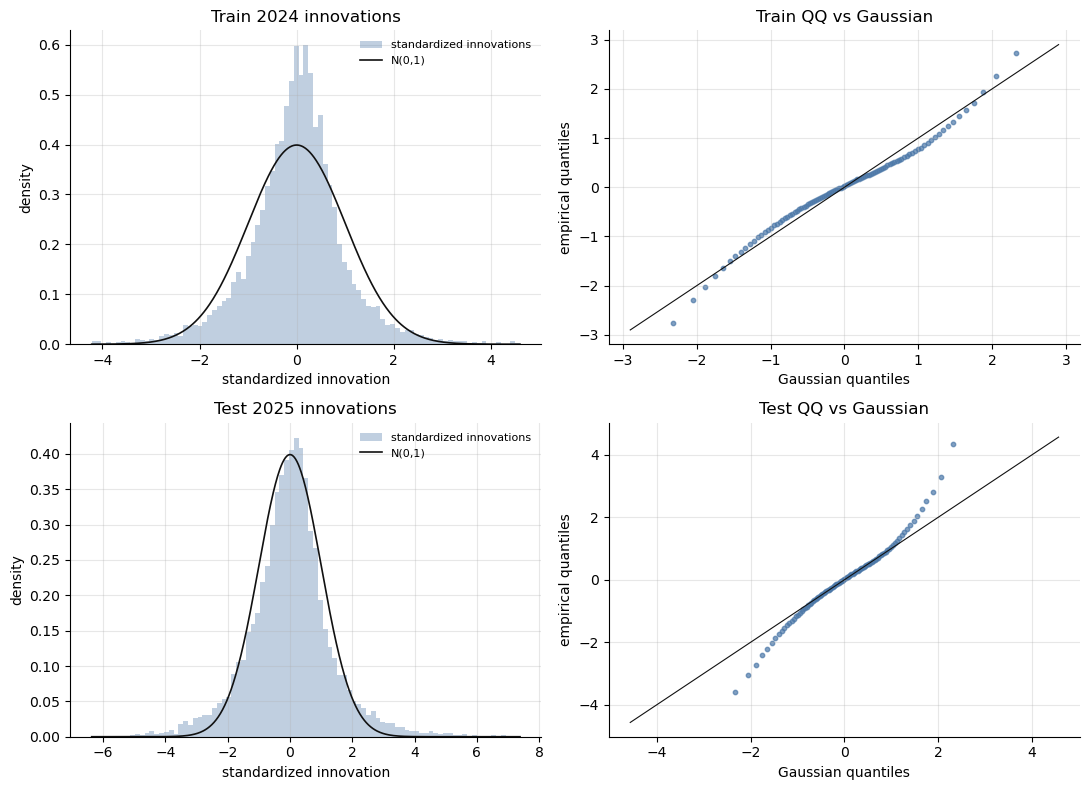

Saved: price_carma43_qmle_innovation_diagnostics.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, eps, title in [
    (axes[0, 0], eps_train, "Train 2024 innovations"),
    (axes[1, 0], eps_test, "Test 2025 innovations"),
]:
    lo, hi = np.quantile(eps, [0.001, 0.999])
    bins = np.linspace(lo, hi, 90)
    x = np.linspace(lo, hi, 600)
    ax.hist(eps, bins=bins, density=True, color="#4c78a8", alpha=0.35, label="standardized innovations")
    ax.plot(x, norm.pdf(x), color="#111111", lw=1.2, label="N(0,1)")
    ax.set_title(title)
    ax.set_xlabel("standardized innovation")
    ax.set_ylabel("density")
    ax.legend(frameon=False, fontsize=8)

probs = np.linspace(0.01, 0.99, 99)
for ax, eps, title in [
    (axes[0, 1], eps_train, "Train QQ vs Gaussian"),
    (axes[1, 1], eps_test, "Test QQ vs Gaussian"),
]:
    emp_q = np.quantile(eps, probs)
    norm_q = norm.ppf(probs)
    lim = max(abs(emp_q).max(), abs(norm_q).max()) * 1.05
    ax.scatter(norm_q, emp_q, s=10, color="#4c78a8", alpha=0.7)
    ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
    ax.set_title(title)
    ax.set_xlabel("Gaussian quantiles")
    ax.set_ylabel("empirical quantiles")

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_qmle_innovation_diagnostics.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 3. Recover 2024 Levy increments

The recovery is done on the 2024 training sample only. It uses the QMLE estimates above,
Kalman filtering, RTS smoothing, and the Brockwell-Lindner modal recovery identity.


In [5]:
def kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, series):
    series = np.asarray(series, dtype=float)
    n = len(series)
    p = A.shape[0]

    x_pred = np.zeros(p)
    P_pred = Pi1.copy()

    pred_states = np.empty((n, p))
    pred_covs = np.empty((n, p, p))
    filt_states = np.empty((n, p))
    filt_covs = np.empty((n, p, p))
    next_pred_states = np.empty((n, p))
    next_pred_covs = np.empty((n, p, p))
    residuals = np.empty(n)
    r_array = np.empty(n)

    for i in range(n):
        pred_states[i] = x_pred
        pred_covs[i] = P_pred

        P_b = P_pred @ b_vec
        Delta_i = float(b_vec @ P_b)
        if Delta_i <= 0:
            raise RuntimeError(f"Delta[{i + 1}]={Delta_i:.6e} <= 0")

        resid = series[i] - float(b_vec @ x_pred)
        gain = P_b / Delta_i
        x_filt = x_pred + gain * resid
        P_filt = P_pred - np.outer(P_b, P_b) / Delta_i
        P_filt = 0.5 * (P_filt + P_filt.T)

        x_next = F @ x_filt
        P_next = F @ P_filt @ F.T + Q_base
        P_next = 0.5 * (P_next + P_next.T)

        residuals[i] = resid
        r_array[i] = Delta_i
        filt_states[i] = x_filt
        filt_covs[i] = P_filt
        next_pred_states[i] = x_next
        next_pred_covs[i] = P_next

        x_pred = x_next
        P_pred = P_next

    return {
        "residuals": residuals,
        "r_array": r_array,
        "pred_states": pred_states,
        "pred_covs": pred_covs,
        "filt_states": filt_states,
        "filt_covs": filt_covs,
        "next_pred_states": next_pred_states,
        "next_pred_covs": next_pred_covs,
    }


def rts_smoother(F, filt_states, filt_covs, next_pred_states, next_pred_covs):
    n, p = filt_states.shape
    smooth_states = filt_states.copy()
    smooth_covs = filt_covs.copy()

    for i in range(n - 2, -1, -1):
        J = np.linalg.solve(next_pred_covs[i].T, (filt_covs[i] @ F.T).T).T
        smooth_states[i] = filt_states[i] + J @ (smooth_states[i + 1] - next_pred_states[i])
        smooth_covs[i] = filt_covs[i] + J @ (smooth_covs[i + 1] - next_pred_covs[i]) @ J.T
        smooth_covs[i] = 0.5 * (smooth_covs[i] + smooth_covs[i].T)

    return smooth_states, smooth_covs


def parse_roots(ar_coeffs, roots=None):
    if roots is None:
        return np.roots(np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)]))
    return np.array([r[0] + 1j * r[1] if hasattr(r, "__len__") else complex(r) for r in roots])


def build_modal_matrix(A, roots_complex):
    roots_complex = np.asarray(roots_complex, dtype=complex)
    p = len(roots_complex)
    E = np.column_stack([lam ** np.arange(p) for lam in roots_complex])
    for r, lam in enumerate(roots_complex):
        err = np.linalg.norm(A @ E[:, r] - lam * E[:, r])
        if err >= 1e-8:
            raise ValueError(f"Eigenvector check failed for root {r}: err={err:.3e}")
    return E, np.linalg.inv(E)


def select_recovery_root(roots_complex, tol=1e-8):
    real_mask = np.abs(roots_complex.imag) < tol
    if not np.any(real_mask):
        raise ValueError("No real root available for modal recovery.")
    ridx = np.where(real_mask)[0]
    return int(ridx[np.argmin(np.abs(roots_complex[ridx].real))])


def levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=None, Delta=1.0):
    X_hat = np.asarray(X_hat, dtype=float)
    roots_complex = parse_roots(ar_coeffs, roots)
    A_loc = build_companion_matrix(ar_coeffs)
    _, E_inv = build_modal_matrix(A_loc, roots_complex)

    idx_r = select_recovery_root(roots_complex)
    lam_r = float(roots_complex[idx_r].real)

    b_lam = float(sum(c * lam_r ** k for k, c in enumerate(b_coeffs)))
    xi_r = (E_inv @ X_hat.T)[idx_r]
    imag_frac = np.abs(xi_r.imag).max() / (np.abs(xi_r.real).max() + 1e-30)
    if imag_frac > 1e-6:
        raise ValueError(f"Imaginary residual too large in modal coordinate: {imag_frac:.2e}")

    Y_r = b_lam * xi_r.real
    a_desc = np.concatenate([[1.0], np.asarray(ar_coeffs, dtype=float)])
    a_prime = float(np.polyval(np.polyder(a_desc), lam_r))
    alpha_r = b_lam / a_prime

    times = np.arange(len(Y_r)) * Delta
    integ = cumulative_trapezoid(Y_r, times, initial=0.0)
    L_hat = (Y_r - Y_r[0] - lam_r * integ) / alpha_r

    return {
        "L_hat": L_hat,
        "increments": np.diff(L_hat),
        "Y_r": Y_r,
        "lambda_r": lam_r,
        "idx_r": idx_r,
        "alpha_r": float(alpha_r),
    }


def recover_levy_increments(y, ar_coeffs, b_coeffs, m_hat, nu2_hat, roots=None, Delta=1.0):
    y = np.asarray(y, dtype=float)
    p = len(ar_coeffs)
    A_loc = build_companion_matrix(ar_coeffs)
    ep_loc = np.zeros(p)
    ep_loc[-1] = 1.0
    b_loc = build_b_vector(b_coeffs, p)
    F_loc = expm(A_loc * Delta)
    Pi1_loc = solve_continuous_lyapunov(A_loc, -np.outer(ep_loc, ep_loc))
    Qb_loc = discrete_noise_covariance(A_loc, ep_loc, Delta)
    dc = float(b_coeffs[0] / ar_coeffs[-1])

    W = y - m_hat * dc
    filt = kalman_filter_state_estimates(A_loc, b_loc, F_loc, Qb_loc, Pi1_loc, W)
    U_smooth, U_smooth_cov = rts_smoother(
        F_loc,
        filt["filt_states"],
        filt["filt_covs"],
        filt["next_pred_states"],
        filt["next_pred_covs"],
    )

    obs_resid = W - U_smooth @ b_loc
    shift = np.linalg.solve(-A_loc, ep_loc)
    X_hat = U_smooth + m_hat * shift

    out = levy_path_from_states(X_hat, ar_coeffs, b_coeffs, roots=roots, Delta=Delta)
    out["state_path"] = X_hat
    out["smooth_covs"] = U_smooth_cov
    out["obs_resid_max"] = float(np.max(np.abs(obs_resid)))
    out["nu2_hat"] = float(nu2_hat)
    out["m_hat"] = float(m_hat)
    return out


levy_out = recover_levy_increments(
    y_train,
    ar_coefficients,
    b_coefficients,
    m_hat=m_hat,
    nu2_hat=nu2_hat,
    roots=cfg["roots"],
    Delta=Delta,
)

L_hat = levy_out["L_hat"]
driver_delta_l = levy_out["increments"]
dL = np.asarray(driver_delta_l, dtype=float)

levy_npz_path = OUT / f"price_{model_tag}_levy_increments_recovered_2024.npz"
levy_generic_npz_path = OUT / f"price_{model_tag}_levy_increments_recovered.npz"
np.savez(
    levy_npz_path,
    L_hat=L_hat,
    increments=dL,
    Y_r=levy_out["Y_r"],
    lambda_r=np.array([levy_out["lambda_r"]]),
    idx_r=np.array([levy_out["idx_r"]], dtype=int),
    alpha_r=np.array([levy_out["alpha_r"]]),
    state_path=levy_out["state_path"],
    nu2_hat=np.array([nu2_hat]),
    m_hat=np.array([m_hat]),
    obs_resid_max=np.array([levy_out["obs_resid_max"]]),
    sample=np.array(["2024_train"]),
)
np.savez(
    levy_generic_npz_path,
    L_hat=L_hat,
    increments=dL,
    Y_r=levy_out["Y_r"],
    lambda_r=np.array([levy_out["lambda_r"]]),
    idx_r=np.array([levy_out["idx_r"]], dtype=int),
    alpha_r=np.array([levy_out["alpha_r"]]),
    state_path=levy_out["state_path"],
    nu2_hat=np.array([nu2_hat]),
    m_hat=np.array([m_hat]),
    obs_resid_max=np.array([levy_out["obs_resid_max"]]),
    sample=np.array(["2024_train"]),
)

recovery_half_life_h = np.log(2.0) / (-levy_out["lambda_r"])
recovery_summary = pd.DataFrame({
    "recovered_DeltaL_2024": distribution_summary(dL),
    "qmle_standardized_innovations_2024": distribution_summary(eps_train),
}).T
recovery_summary_path = OUT / f"price_{model_tag}_levy_recovery_summary_2024.csv"
recovery_summary.to_csv(recovery_summary_path)

print(f"Selected recovery root lambda = {levy_out['lambda_r']:.6e}")
print(f"Selected recovery root half-life = {recovery_half_life_h:.3f} h = {recovery_half_life_h / 24.0:.3f} d")
print(f"Recovered Delta L mean/std    = {dL.mean():.6e} / {dL.std(ddof=0):.6e}")
print(f"Recovered Delta L var / nu2   = {np.var(dL, ddof=0) / nu2_hat:.6f}")
print(f"Max smoother observation residual = {levy_out['obs_resid_max']:.3e}")
print(f"Saved: {levy_npz_path.name}")
print(f"Saved: {levy_generic_npz_path.name}")
print(f"Saved: {recovery_summary_path.name}")
display(recovery_summary.style.format("{:.6e}"))


Selected recovery root lambda = -2.631780e-02
Selected recovery root half-life = 26.338 h = 1.097 d
Recovered Delta L mean/std    = 6.912286e-07 / 9.598995e-03
Recovered Delta L var / nu2   = 0.995192
Max smoother observation residual = 3.123e-17
Saved: price_carma43_levy_increments_recovered_2024.npz
Saved: price_carma43_levy_increments_recovered.npz
Saved: price_carma43_levy_recovery_summary_2024.csv


,mean,std,q01,q05,median,q95,q99,skew,excess_kurtosis
recovered_DeltaL_2024,6.912286e-07,9.598995e-03,-2.652645e-02,-1.575970e-02,2.761563e-04,1.514437e-02,2.612370e-02,5.158470e-02,3.177708e+00
qmle_standardized_innovations_2024,2.182568e-03,9.999976e-01,-2.760957e+00,-1.640406e+00,3.064795e-02,1.580256e+00,2.723852e+00,5.064813e-02,3.175733e+00


## 4. Fit Gaussian and NIG laws to recovered 2024 `Delta L`

These fits are driver fits on the recovered 2024 Levy increments. They are not fitted
to `Delta Y`, and no 2025 information is used.


In [6]:
def log_nig_pdf_save03(x, mu, delta, alpha, beta):
    x = np.asarray(x, dtype=float)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    xm = x - mu
    r = np.sqrt(delta * delta + xm * xm)
    return (
        np.log(alpha * delta / np.pi)
        + delta * gamma
        + beta * xm
        + np.log(kve(1, alpha * r))
        - alpha * r
        - np.log(r)
    )


def fit_nig_manual(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    mu_g = float(x.mean())
    sig_g = float(x.std(ddof=1))
    kurt_raw = float(np.mean((x - mu_g) ** 4) / sig_g ** 4)
    skew_raw = float(np.mean((x - mu_g) ** 3) / sig_g ** 3)

    alpha0 = np.sqrt(3.0 / (sig_g ** 2 * max(kurt_raw - 3.0, 0.01)))
    delta0 = sig_g ** 2 * alpha0
    beta0 = np.clip(
        skew_raw * alpha0 * np.sqrt(delta0 * alpha0) / 3.0,
        -0.9 * alpha0,
        0.9 * alpha0,
    )

    def pack(mu, delta, alpha, beta):
        return np.array([mu, np.log(delta), np.log(alpha), np.arctanh(beta / (0.99 * alpha))])

    def unpack(theta):
        mu = theta[0]
        delta = np.exp(theta[1])
        alpha = np.exp(theta[2])
        beta = np.tanh(theta[3]) * 0.99 * alpha
        return mu, delta, alpha, beta

    def nll(theta):
        mu, delta, alpha, beta = unpack(theta)
        ll = log_nig_pdf_save03(x, mu, delta, alpha, beta)
        if not np.all(np.isfinite(ll)):
            return 1e50
        return -float(ll.sum())

    theta0 = pack(mu_g, delta0, alpha0, beta0)
    best = None
    for beta_shift in np.linspace(-0.5, 0.5, 5):
        res = minimize(
            nll,
            theta0 + np.array([0.0, 0.0, 0.0, beta_shift]),
            method="L-BFGS-B",
            options={"maxiter": 800, "ftol": 1e-10},
        )
        if best is None or res.fun < best.fun:
            best = res

    mu, delta, alpha, beta = unpack(best.x)
    gamma = np.sqrt(alpha * alpha - beta * beta)
    return {
        "mu": float(mu),
        "delta": float(delta),
        "alpha": float(alpha),
        "beta": float(beta),
        "gamma": float(gamma),
        "scipy_a": float(alpha * delta),
        "scipy_b": float(beta * delta),
        "scipy_loc": float(mu),
        "scipy_scale": float(delta),
        "loglik": float(-best.fun),
        "mean": float(mu + delta * beta / gamma),
        "variance": float(delta * alpha * alpha / gamma ** 3),
        "std": float(np.sqrt(delta * alpha * alpha / gamma ** 3)),
        "skew": float(3 * beta / (alpha * np.sqrt(delta * gamma))),
        "excess_kurtosis": float(3 * (1 + 4 * beta * beta / (alpha * alpha)) / (delta * gamma)),
        "success": bool(best.success),
        "message": str(best.message),
        "N": int(len(x)),
    }


gaussian_driver = {
    "mean": float(dL.mean()),
    "variance": float(dL.var(ddof=0)),
    "std": float(dL.std(ddof=0)),
    "m_rate": float(dL.mean() / Delta),
    "nu2_rate": float(dL.var(ddof=0) / Delta),
    "loglik": float(np.sum(norm.logpdf(dL, dL.mean(), dL.std(ddof=0)))),
    "N": int(len(dL)),
}
nig_driver = fit_nig_manual(dL)

driver_fits = {
    "gaussian": gaussian_driver,
    "nig": nig_driver,
    "sample": "2024_train",
    "source": "recovered hourly Levy increments from france/france24vs25/03check.ipynb",
    "qmle_source": str(qmle_path.relative_to(CHECK_DIR)),
}
driver_fits_path = OUT / f"price_{model_tag}_driver_fits_2024.json"
driver_fits_generic_path = OUT / f"price_{model_tag}_driver_fits.json"
driver_fits_path.write_text(json.dumps(driver_fits, indent=2))
driver_fits_generic_path.write_text(json.dumps(driver_fits, indent=2))

driver_fit_summary = pd.DataFrame({
    "recovered_DeltaL_2024": distribution_summary(dL),
    "gaussian_fit_DeltaL": pd.Series({
        "mean": gaussian_driver["mean"],
        "std": gaussian_driver["std"],
        "q01": norm.ppf(0.01, gaussian_driver["mean"], gaussian_driver["std"]),
        "q05": norm.ppf(0.05, gaussian_driver["mean"], gaussian_driver["std"]),
        "median": gaussian_driver["mean"],
        "q95": norm.ppf(0.95, gaussian_driver["mean"], gaussian_driver["std"]),
        "q99": norm.ppf(0.99, gaussian_driver["mean"], gaussian_driver["std"]),
        "skew": 0.0,
        "excess_kurtosis": 0.0,
    }),
    "nig_fit_DeltaL": pd.Series({
        "mean": nig_driver["mean"],
        "std": nig_driver["std"],
        "q01": norminvgauss.ppf(0.01, nig_driver["scipy_a"], nig_driver["scipy_b"],
                                loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        "q05": norminvgauss.ppf(0.05, nig_driver["scipy_a"], nig_driver["scipy_b"],
                                loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        "median": norminvgauss.ppf(0.50, nig_driver["scipy_a"], nig_driver["scipy_b"],
                                   loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        "q95": norminvgauss.ppf(0.95, nig_driver["scipy_a"], nig_driver["scipy_b"],
                                loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        "q99": norminvgauss.ppf(0.99, nig_driver["scipy_a"], nig_driver["scipy_b"],
                                loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        "skew": nig_driver["skew"],
        "excess_kurtosis": nig_driver["excess_kurtosis"],
    }),
}).T

driver_summary_path = OUT / f"price_{model_tag}_driver_fit_summary_2024.csv"
driver_fit_summary.to_csv(driver_summary_path)

print("Gaussian driver fit on 2024 Delta L")
print(f"  mean/std = {gaussian_driver['mean']:.6e} / {gaussian_driver['std']:.6e}")
print(f"  loglik   = {gaussian_driver['loglik']:.3f}")
print("NIG driver fit on 2024 Delta L")
print(f"  mu,delta,alpha,beta = {nig_driver['mu']:.6e}, {nig_driver['delta']:.6e}, {nig_driver['alpha']:.6e}, {nig_driver['beta']:.6e}")
print(f"  mean/std            = {nig_driver['mean']:.6e} / {nig_driver['std']:.6e}")
print(f"  skew/kurt           = {nig_driver['skew']:.4f} / {nig_driver['excess_kurtosis']:.4f}")
print(f"  loglik              = {nig_driver['loglik']:.3f}")
print(f"Saved: {driver_fits_path.name}")
print(f"Saved: {driver_fits_generic_path.name}")
print(f"Saved: {driver_summary_path.name}")
display(driver_fit_summary.style.format("{:.6e}"))


Gaussian driver fit on 2024 Delta L
  mean/std = 6.912286e-07 / 9.598995e-03
  loglik   = 28344.132
NIG driver fit on 2024 Delta L
  mu,delta,alpha,beta = 5.579780e-04, 8.038965e-03, 8.637077e+01, -5.973165e+00
  mean/std            = 6.908965e-07 / 9.682294e-03
  skew/kurt           = -0.2493 / 4.4139
  loglik              = 28931.663
Saved: price_carma43_driver_fits_2024.json
Saved: price_carma43_driver_fits.json
Saved: price_carma43_driver_fit_summary_2024.csv


,mean,std,q01,q05,median,q95,q99,skew,excess_kurtosis
recovered_DeltaL_2024,6.912286e-07,9.598995e-03,-2.652645e-02,-1.575970e-02,2.761563e-04,1.514437e-02,2.612370e-02,5.158470e-02,3.177708e+00
gaussian_fit_DeltaL,6.912286e-07,9.598995e-03,-2.232991e-02,-1.578825e-02,6.912286e-07,1.578963e-02,2.233129e-02,0.000000e+00,0.000000e+00
nig_fit_DeltaL,6.908965e-07,9.682294e-03,-2.802046e-02,-1.552497e-02,2.087518e-04,1.481443e-02,2.586864e-02,-2.492850e-01,4.413929e+00


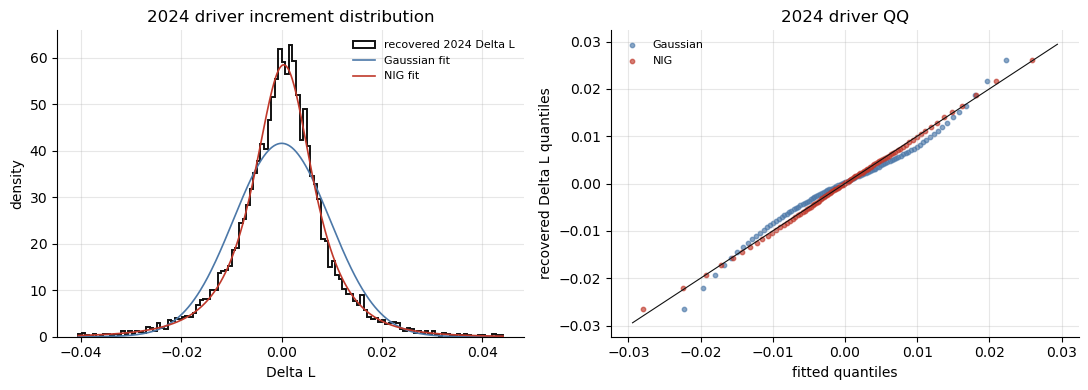

Saved: price_carma43_driver_deltaL_fits_2024.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0]
bins = np.linspace(np.quantile(dL, 0.001), np.quantile(dL, 0.999), 120)
x = np.linspace(bins[0], bins[-1], 700)
ax.hist(dL, bins=bins, density=True, histtype="step", color="#111111", lw=1.4, label="recovered 2024 Delta L")
ax.plot(x, norm.pdf(x, gaussian_driver["mean"], gaussian_driver["std"]),
        color="#4c78a8", lw=1.2, label="Gaussian fit")
ax.plot(x, norminvgauss.pdf(x, nig_driver["scipy_a"], nig_driver["scipy_b"],
                            loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"]),
        color="#c0392b", lw=1.2, label="NIG fit")
ax.set_title("2024 driver increment distribution")
ax.set_xlabel("Delta L")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[1]
obs_q = np.quantile(dL, probs)
gauss_q = norm.ppf(probs, gaussian_driver["mean"], gaussian_driver["std"])
nig_q = norminvgauss.ppf(probs, nig_driver["scipy_a"], nig_driver["scipy_b"],
                         loc=nig_driver["scipy_loc"], scale=nig_driver["scipy_scale"])
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("2024 driver QQ")
ax.set_xlabel("fitted quantiles")
ax.set_ylabel("recovered Delta L quantiles")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_driver_deltaL_fits_2024.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 5. 2024 distribution, QQ, and ACF checks

This section simulates the selected CARMA model with the Gaussian and NIG driver fits
estimated from 2024 recovered increments. The comparison remains in-sample on 2024.


In [8]:
def psd_sqrt(M, tol=1e-12):
    M = 0.5 * (M + M.T)
    vals, vecs = np.linalg.eigh(M)
    if vals.min() < -tol:
        raise ValueError(f"Matrix is not PSD; min eigenvalue={vals.min():.3e}")
    return vecs @ np.diag(np.sqrt(np.clip(vals, 0.0, None)))


def simulate_gaussian_carma_exact(A, b_vec, F, Q_base, Pi1, ep, driver_fit,
                                  n_steps, n_paths, seed=20260621):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    m_rate = driver_fit["m_rate"]
    nu2_rate = driver_fit["nu2_rate"]

    state_mean = m_rate * np.linalg.solve(-A, ep)
    pi_sqrt = psd_sqrt(Pi1)
    q_sqrt = psd_sqrt(Q_base)
    g = np.linalg.solve(A, (F - np.eye(p)) @ ep)

    X = state_mean + np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ pi_sqrt.T)
    Y = np.empty((n_paths, n_steps))

    for t in range(n_steps):
        shocks = np.sqrt(nu2_rate) * (rng.standard_normal((n_paths, p)) @ q_sqrt.T)
        X = X @ F.T + m_rate * g + shocks
        Y[:, t] = X @ b_vec

    return Y


def simulate_nig_carma_midpoint(A, b_vec, F, ep, nig_fit,
                                n_steps, n_paths, burnin=5000, seed=20260622):
    rng = np.random.default_rng(seed)
    p = A.shape[0]
    shock_vec = expm(A * 0.5) @ ep
    mean_dL = nig_fit["mean"]
    state_mean = np.linalg.solve(np.eye(p) - F, shock_vec * mean_dL)

    X = np.tile(state_mean, (n_paths, 1))
    Y = np.empty((n_paths, n_steps))

    dL_all = norminvgauss.rvs(
        nig_fit["scipy_a"],
        nig_fit["scipy_b"],
        loc=nig_fit["scipy_loc"],
        scale=nig_fit["scipy_scale"],
        size=(n_paths, n_steps + burnin),
        random_state=rng,
    )

    out_i = 0
    for t in range(n_steps + burnin):
        X = X @ F.T + dL_all[:, t, None] * shock_vec
        if t >= burnin:
            Y[:, out_i] = X @ b_vec
            out_i += 1

    return Y, dL_all[:, burnin:]


N_PATHS_2024 = 250
gaussian_train_paths = simulate_gaussian_carma_exact(
    A, b_vec, F, Q_base, Pi1, ep, gaussian_driver,
    n_steps=len(y_train), n_paths=N_PATHS_2024, seed=20260621,
)
nig_train_paths, nig_driver_draws = simulate_nig_carma_midpoint(
    A, b_vec, F, ep, nig_driver,
    n_steps=len(y_train), n_paths=N_PATHS_2024, burnin=5000, seed=20260622,
)

obs_delta_y_train = np.diff(y_train)
gaussian_train_delta_y = np.diff(gaussian_train_paths, axis=1)
nig_train_delta_y = np.diff(nig_train_paths, axis=1)

distribution_2024 = pd.DataFrame({
    "observed_2024_Y": distribution_summary(y_train),
    "gaussian_CARMA_2024_Y": distribution_summary(gaussian_train_paths),
    "nig_CARMA_2024_Y": distribution_summary(nig_train_paths),
    "observed_2024_DeltaY": distribution_summary(obs_delta_y_train),
    "gaussian_CARMA_2024_DeltaY": distribution_summary(gaussian_train_delta_y),
    "nig_CARMA_2024_DeltaY": distribution_summary(nig_train_delta_y),
    "recovered_2024_DeltaL": distribution_summary(dL),
    "nig_simulated_2024_DeltaL": distribution_summary(nig_driver_draws),
}).T

distribution_2024_path = OUT / f"price_{model_tag}_2024_distribution_summary.csv"
distribution_2024.to_csv(distribution_2024_path)

acf_max_lag_2024 = 336
acf_lags = np.arange(acf_max_lag_2024 + 1)
acf_obs_2024 = acf_1d(y_train, acf_max_lag_2024)
acf_gaussian_2024 = np.mean([acf_1d(path, acf_max_lag_2024) for path in gaussian_train_paths], axis=0)
acf_nig_2024 = np.mean([acf_1d(path, acf_max_lag_2024) for path in nig_train_paths], axis=0)

acf_2024_table = pd.DataFrame({
    "lag_h": acf_lags,
    "observed_2024": acf_obs_2024,
    "gaussian_CARMA": acf_gaussian_2024,
    "nig_CARMA": acf_nig_2024,
})
acf_2024_path = OUT / f"price_{model_tag}_2024_acf_simulation_comparison.csv"
acf_2024_table.to_csv(acf_2024_path, index=False)

acf_diag_lags = [1, 2, 3, 6, 12, 24, 48, 72, 168, 336]
acf_diag_table = acf_2024_table.loc[acf_2024_table["lag_h"].isin(acf_diag_lags)]

print(f"Gaussian exact CARMA paths: {gaussian_train_paths.shape}")
print(f"NIG midpoint CARMA paths  : {nig_train_paths.shape}")
print(f"Observed 2024 Y mean/std  : {y_train.mean():.6e} / {y_train.std(ddof=0):.6e}")
print(f"Gaussian 2024 Y mean/std  : {gaussian_train_paths.mean():.6e} / {gaussian_train_paths.std(ddof=0):.6e}")
print(f"NIG 2024 Y mean/std       : {nig_train_paths.mean():.6e} / {nig_train_paths.std(ddof=0):.6e}")
print(f"Saved: {distribution_2024_path.name}")
print(f"Saved: {acf_2024_path.name}")
display(distribution_2024.style.format("{:.6e}"))
display(acf_diag_table.style.format("{:.6f}").hide(axis="index"))


Gaussian exact CARMA paths: (250, 8784)
NIG midpoint CARMA paths  : (250, 8784)
Observed 2024 Y mean/std  : 3.577562e-15 / 2.374614e-02
Gaussian 2024 Y mean/std  : 9.505885e-05 / 2.278086e-02
NIG 2024 Y mean/std       : -1.218773e-04 / 2.286827e-02
Saved: price_carma43_2024_distribution_summary.csv
Saved: price_carma43_2024_acf_simulation_comparison.csv


,mean,std,q01,q05,median,q95,q99,skew,excess_kurtosis
observed_2024_Y,3.577562e-15,2.374614e-02,-5.801909e-02,-4.129602e-02,9.032588e-04,3.751676e-02,5.322750e-02,-1.085349e-01,5.433237e-01
gaussian_CARMA_2024_Y,9.505885e-05,2.278086e-02,-5.302939e-02,-3.751374e-02,1.415710e-04,3.744517e-02,5.300739e-02,-6.195001e-03,1.473187e-04
nig_CARMA_2024_Y,-1.218773e-04,2.286827e-02,-5.521487e-02,-3.797664e-02,9.940859e-05,3.698488e-02,5.312624e-02,-5.767224e-02,1.983575e-01
observed_2024_DeltaY,-9.070201e-07,8.671157e-03,-2.467355e-02,-1.381622e-02,2.310836e-04,1.380674e-02,2.463123e-02,2.908752e-02,3.415008e+00
gaussian_CARMA_2024_DeltaY,-1.674423e-07,8.793496e-03,-2.047950e-02,-1.445907e-02,2.438585e-06,1.445993e-02,2.045543e-02,-2.672930e-03,8.601668e-05
nig_CARMA_2024_DeltaY,-1.202857e-07,8.787308e-03,-2.504543e-02,-1.408949e-02,1.611217e-04,1.350049e-02,2.314156e-02,-2.231311e-01,3.800790e+00
recovered_2024_DeltaL,6.912286e-07,9.598995e-03,-2.652645e-02,-1.575970e-02,2.761563e-04,1.514437e-02,2.612370e-02,5.158470e-02,3.177708e+00
nig_simulated_2024_DeltaL,-6.500218e-06,9.673723e-03,-2.807880e-02,-1.554073e-02,2.050778e-04,1.479871e-02,2.581021e-02,-2.485072e-01,4.303674e+00


lag_h,observed_2024,gaussian_CARMA,nig_CARMA
1.000000,0.932581,0.924297,0.925091
2.000000,0.863269,0.868851,0.870173
3.000000,0.810173,0.825049,0.826883
6.000000,0.708211,0.725280,0.727386
12.000000,0.608778,0.589689,0.591625
24.000000,0.499070,0.462787,0.465348
48.000000,0.261760,0.244063,0.245316
72.000000,0.153883,0.126385,0.125107
168.000000,-0.054192,0.000311,0.010013
336.000000,-0.017477,-0.007151,-0.010114


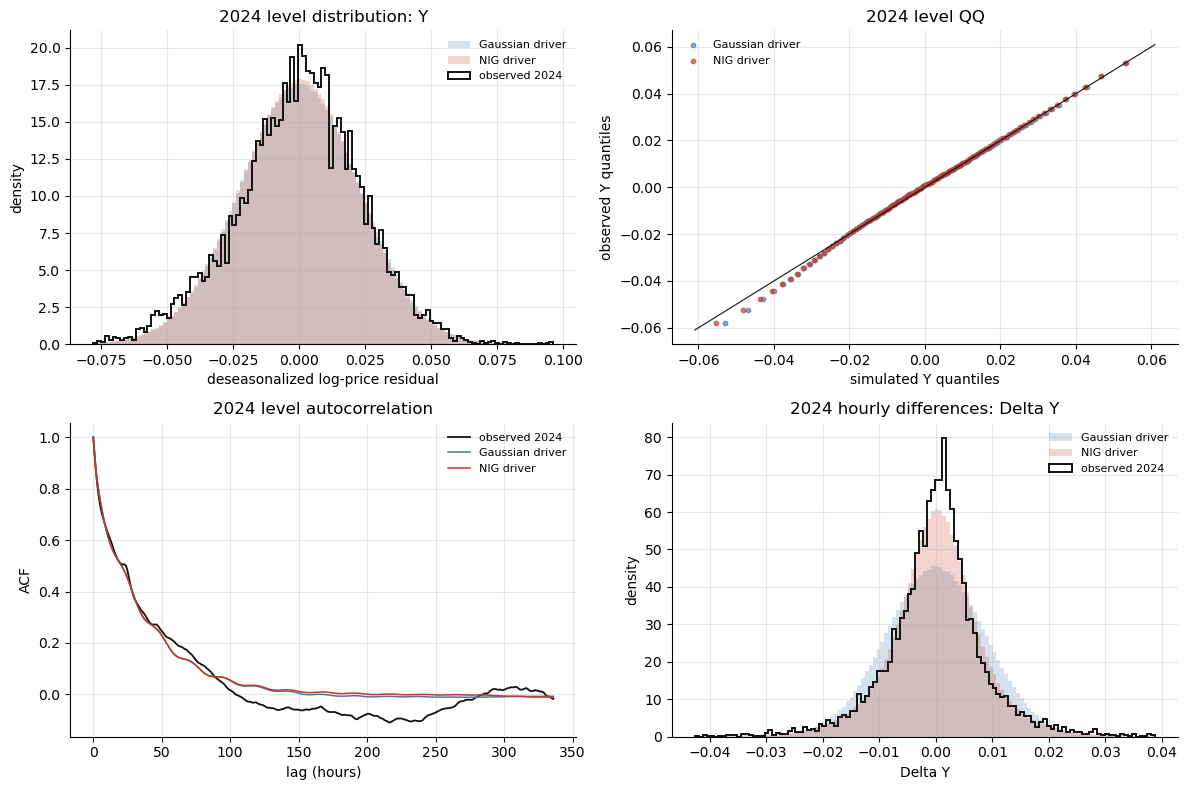

Saved: price_carma43_2024_distribution_qq_acf.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
probs = np.linspace(0.01, 0.99, 99)

ax = axes[0, 0]
bins_y = np.linspace(
    min(np.quantile(y_train, 0.001), np.quantile(gaussian_train_paths, 0.001), np.quantile(nig_train_paths, 0.001)),
    max(np.quantile(y_train, 0.999), np.quantile(gaussian_train_paths, 0.999), np.quantile(nig_train_paths, 0.999)),
    120,
)
ax.hist(gaussian_train_paths.ravel(), bins=bins_y, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_train_paths.ravel(), bins=bins_y, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(y_train, bins=bins_y, density=True, histtype="step", color="#111111", lw=1.4, label="observed 2024")
ax.set_title("2024 level distribution: Y")
ax.set_xlabel("deseasonalized log-price residual")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
obs_q = np.quantile(y_train, probs)
gauss_q = np.quantile(gaussian_train_paths.ravel(), probs)
nig_q = np.quantile(nig_train_paths.ravel(), probs)
lim = max(abs(obs_q).max(), abs(gauss_q).max(), abs(nig_q).max()) * 1.05
ax.scatter(gauss_q, obs_q, s=10, color="#4c78a8", alpha=0.65, label="Gaussian driver")
ax.scatter(nig_q, obs_q, s=10, color="#c0392b", alpha=0.65, label="NIG driver")
ax.plot([-lim, lim], [-lim, lim], color="#111111", lw=0.8)
ax.set_title("2024 level QQ")
ax.set_xlabel("simulated Y quantiles")
ax.set_ylabel("observed Y quantiles")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 0]
ax.plot(acf_lags, acf_obs_2024, color="#111111", lw=1.3, label="observed 2024")
ax.plot(acf_lags, acf_gaussian_2024, color="#4c78a8", lw=1.1, label="Gaussian driver")
ax.plot(acf_lags, acf_nig_2024, color="#c0392b", lw=1.1, label="NIG driver")
ax.set_title("2024 level autocorrelation")
ax.set_xlabel("lag (hours)")
ax.set_ylabel("ACF")
ax.legend(frameon=False, fontsize=8)

ax = axes[1, 1]
bins_dy = np.linspace(
    min(np.quantile(obs_delta_y_train, 0.001), np.quantile(gaussian_train_delta_y, 0.001), np.quantile(nig_train_delta_y, 0.001)),
    max(np.quantile(obs_delta_y_train, 0.999), np.quantile(gaussian_train_delta_y, 0.999), np.quantile(nig_train_delta_y, 0.999)),
    120,
)
ax.hist(gaussian_train_delta_y.ravel(), bins=bins_dy, density=True, color="#4c78a8", alpha=0.22, label="Gaussian driver")
ax.hist(nig_train_delta_y.ravel(), bins=bins_dy, density=True, color="#c0392b", alpha=0.22, label="NIG driver")
ax.hist(obs_delta_y_train, bins=bins_dy, density=True, histtype="step", color="#111111", lw=1.4, label="observed 2024")
ax.set_title("2024 hourly differences: Delta Y")
ax.set_xlabel("Delta Y")
ax.set_ylabel("density")
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_2024_distribution_qq_acf.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 6. 24h-ahead price forecasts on 2025

The forecast is conditional. A Kalman filter is run on the 2024+2025 residual sequence
with parameters fixed from 2024. For each 2025 target hour, the state available 24 hours
earlier is propagated forward by `F^24`, then recombined with the known seasonal component
to forecast log-price and raw price.


In [10]:
def h_step_process_covariance(F, Q_base, h):
    p = F.shape[0]
    Qh = np.zeros((p, p))
    Fr = np.eye(p)
    for _ in range(h):
        Qh += Fr @ Q_base @ Fr.T
        Fr = F @ Fr
    return 0.5 * (Qh + Qh.T)


def forecast_metrics(observed, forecast):
    observed = np.asarray(observed, dtype=float)
    forecast = np.asarray(forecast, dtype=float)
    err = forecast - observed
    corr = np.corrcoef(observed, forecast)[0, 1] if len(observed) > 1 else np.nan
    return pd.Series({
        "n": int(len(observed)),
        "mean_observed": float(np.mean(observed)),
        "mean_forecast": float(np.mean(forecast)),
        "bias": float(np.mean(err)),
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "error_std": float(np.std(err, ddof=0)),
        "corr": float(corr),
        "q05_error": float(np.quantile(err, 0.05)),
        "q50_error": float(np.quantile(err, 0.50)),
        "q95_error": float(np.quantile(err, 0.95)),
    })


H_FORECAST = 24
y_all = np.r_[y_train, y_test]
seasonal_all = np.r_[seasonal_train, seasonal_test]
log_price_all = np.r_[log_price_train, log_price_test]
price_all = np.r_[price_train, price_test]
index_all = panel_all.index

W_all = y_all - stationary_mean
filt_all = kalman_filter_state_estimates(A, b_vec, F, Q_base, Pi1, W_all)
Fh = np.linalg.matrix_power(F, H_FORECAST)
Qh_base = h_step_process_covariance(F, Q_base, H_FORECAST)

target_pos = np.arange(len(y_train), len(y_all))
origin_pos = target_pos - H_FORECAST
if np.any(origin_pos < 0):
    raise ValueError("Not enough history for the requested forecast horizon.")

origin_states = filt_all["filt_states"][origin_pos]
origin_covs = filt_all["filt_covs"][origin_pos]
forecast_zero_mean_y = (origin_states @ Fh.T) @ b_vec
forecast_y = stationary_mean + forecast_zero_mean_y

pred_covs_base = np.einsum("ij,tjk,lk->til", Fh, origin_covs, Fh) + Qh_base[None, :, :]
forecast_y_var = nu2_hat * np.einsum("i,tij,j->t", b_vec, pred_covs_base, b_vec)
forecast_y_sd = np.sqrt(np.maximum(forecast_y_var, 0.0))

forecast_log_price = seasonal_test + forecast_y
forecast_price = np.exp(forecast_log_price) - price_shift
forecast_log_lo95 = seasonal_test + forecast_y - 1.96 * forecast_y_sd
forecast_log_hi95 = seasonal_test + forecast_y + 1.96 * forecast_y_sd
forecast_price_lo95 = np.exp(forecast_log_lo95) - price_shift
forecast_price_hi95 = np.exp(forecast_log_hi95) - price_shift

forecast_2025 = pd.DataFrame({
    "target_time": panel_test.index,
    "origin_time": index_all[origin_pos],
    "horizon_h": H_FORECAST,
    "observed_resid": y_test,
    "forecast_resid": forecast_y,
    "resid_error": forecast_y - y_test,
    "resid_forecast_sd": forecast_y_sd,
    "observed_log_price": log_price_test,
    "forecast_log_price": forecast_log_price,
    "log_price_error": forecast_log_price - log_price_test,
    "observed_price": price_test,
    "forecast_price": forecast_price,
    "price_error": forecast_price - price_test,
    "forecast_price_lo95": forecast_price_lo95,
    "forecast_price_hi95": forecast_price_hi95,
})

forecast_path = OUT / f"price_{model_tag}_24h_ahead_2025_forecasts.csv"
forecast_2025.to_csv(forecast_path, index=False)

forecast_metrics_table = pd.DataFrame({
    "residual_Y": forecast_metrics(y_test, forecast_y),
    "log_price": forecast_metrics(log_price_test, forecast_log_price),
    "raw_price": forecast_metrics(price_test, forecast_price),
}).T

forecast_metrics_path = OUT / f"price_{model_tag}_24h_ahead_2025_metrics.csv"
forecast_metrics_table.to_csv(forecast_metrics_path)

forecast_payload = {
    "model_name": model_name,
    "horizon_h": int(H_FORECAST),
    "calibration_sample": "2024_train",
    "forecast_sample": "2025_test",
    "uses_kalman_filter": True,
    "price_shift": float(price_shift),
    "metrics": forecast_metrics_table.to_dict(orient="index"),
}
forecast_json_path = OUT / f"price_{model_tag}_24h_ahead_2025_metrics.json"
forecast_json_path.write_text(json.dumps(forecast_payload, indent=2))

print(f"24h-ahead forecasts: {len(forecast_2025):,} target hours")
print(f"First target/origin: {forecast_2025['target_time'].iloc[0]} <- {forecast_2025['origin_time'].iloc[0]}")
print(f"Last target/origin : {forecast_2025['target_time'].iloc[-1]} <- {forecast_2025['origin_time'].iloc[-1]}")
print(f"Saved: {forecast_path.name}")
print(f"Saved: {forecast_metrics_path.name}")
print(f"Saved: {forecast_json_path.name}")
display(forecast_metrics_table.style.format("{:.6e}"))


24h-ahead forecasts: 8,760 target hours
First target/origin: 2025-01-01 00:00:00+00:00 <- 2024-12-31 00:00:00+00:00
Last target/origin : 2025-12-31 23:00:00+00:00 <- 2025-12-30 23:00:00+00:00
Saved: price_carma43_24h_ahead_2025_forecasts.csv
Saved: price_carma43_24h_ahead_2025_metrics.csv
Saved: price_carma43_24h_ahead_2025_metrics.json


,n,mean_observed,mean_forecast,bias,mae,rmse,error_std,corr,q05_error,q50_error,q95_error
residual_Y,8.760000e+03,3.077616e-03,1.348586e-03,-1.729030e-03,2.039156e-02,2.590088e-02,2.584311e-02,7.647609e-01,-4.269180e-02,-1.518831e-03,4.046370e-02
log_price,8.760000e+03,6.966493e+00,6.964763e+00,-1.729030e-03,2.039156e-02,2.590088e-02,2.584311e-02,8.101190e-01,-4.269180e-02,-1.518831e-03,4.046370e-02
raw_price,8.760000e+03,6.151822e+01,5.922119e+01,-2.297028e+00,2.178510e+01,2.790316e+01,2.780845e+01,8.081812e-01,-4.669474e+01,-1.573659e+00,4.237581e+01


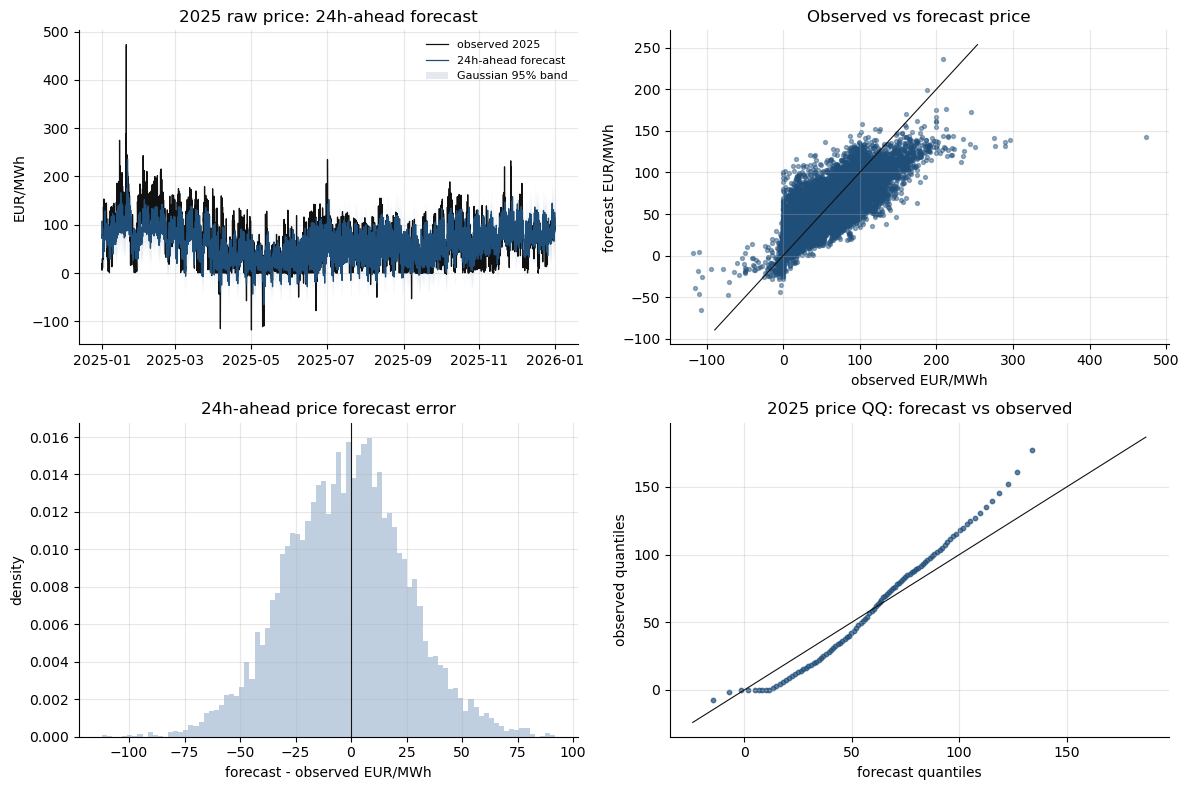

Saved: price_carma43_24h_ahead_price_forecast_2025.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
ax.plot(panel_test.index, price_test, color="#111111", lw=0.9, label="observed 2025")
ax.plot(panel_test.index, forecast_price, color="#1f4e79", lw=0.9, label="24h-ahead forecast")
ax.fill_between(panel_test.index, forecast_price_lo95, forecast_price_hi95,
                color="#1f4e79", alpha=0.12, linewidth=0, label="Gaussian 95% band")
ax.set_title("2025 raw price: 24h-ahead forecast")
ax.set_ylabel("EUR/MWh")
ax.legend(frameon=False, fontsize=8)

ax = axes[0, 1]
lo = min(np.quantile(price_test, 0.001), np.quantile(forecast_price, 0.001))
hi = max(np.quantile(price_test, 0.999), np.quantile(forecast_price, 0.999))
pad = 0.05 * (hi - lo)
ax.scatter(price_test, forecast_price, s=8, alpha=0.45, color="#1f4e79")
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#111111", lw=0.8)
ax.set_title("Observed vs forecast price")
ax.set_xlabel("observed EUR/MWh")
ax.set_ylabel("forecast EUR/MWh")

ax = axes[1, 0]
bins_err = np.linspace(np.quantile(forecast_2025["price_error"], 0.001),
                       np.quantile(forecast_2025["price_error"], 0.999), 90)
ax.hist(forecast_2025["price_error"], bins=bins_err, density=True, color="#4c78a8", alpha=0.35)
ax.axvline(0.0, color="#111111", lw=0.8)
ax.set_title("24h-ahead price forecast error")
ax.set_xlabel("forecast - observed EUR/MWh")
ax.set_ylabel("density")

ax = axes[1, 1]
probs = np.linspace(0.01, 0.99, 99)
obs_q = np.quantile(price_test, probs)
fc_q = np.quantile(forecast_price, probs)
lo = min(obs_q.min(), fc_q.min())
hi = max(obs_q.max(), fc_q.max())
pad = 0.05 * (hi - lo)
ax.scatter(fc_q, obs_q, s=10, color="#1f4e79", alpha=0.7)
ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color="#111111", lw=0.8)
ax.set_title("2025 price QQ: forecast vs observed")
ax.set_xlabel("forecast quantiles")
ax.set_ylabel("observed quantiles")

plt.tight_layout()
fig_path = FIG / f"price_{model_tag}_24h_ahead_price_forecast_2025.png"
plt.savefig(fig_path, dpi=130, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path.name}")


## 7. First-week monthly zooms for 2025

Each panel shows the first seven days of one 2025 month. The forecast remains the same
24h-ahead Kalman forecast computed above.


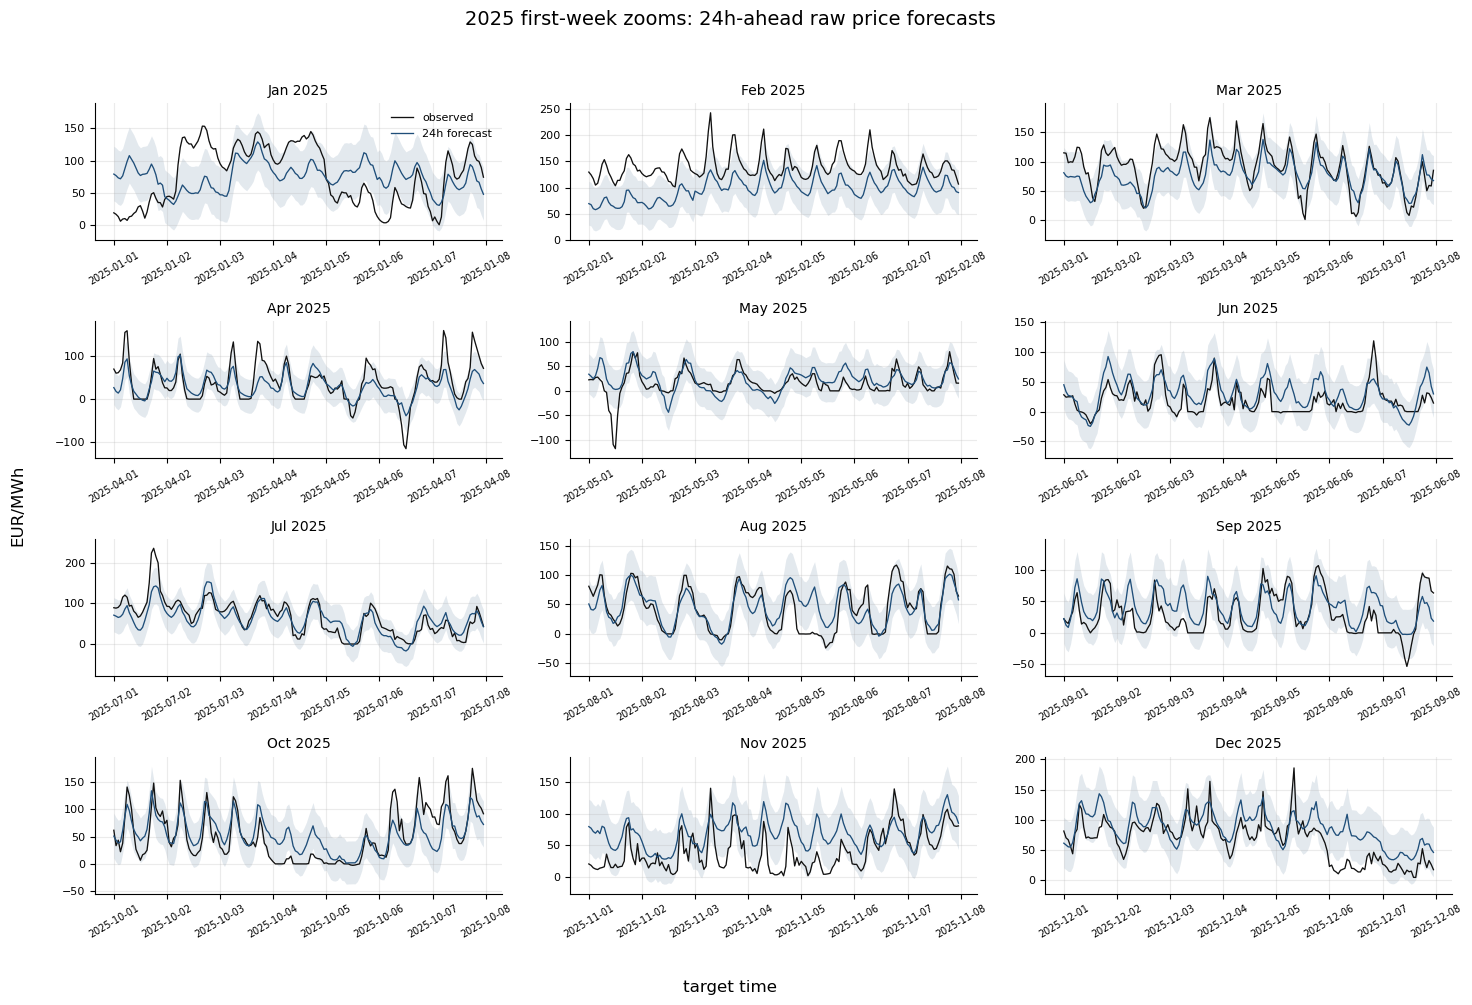

Saved: price_carma43_24h_ahead_first_week_by_month_2025.png
Saved: price_carma43_24h_ahead_first_week_by_month_2025_forecasts.csv
Saved: price_carma43_24h_ahead_first_week_by_month_2025_metrics.csv


,month,start,end,n,mean_observed,mean_forecast,bias,mae,rmse,error_std,corr,q05_error,q50_error,q95_error
0,1,2025-01-01 00:00:00+00:00,2025-01-07 23:00:00+00:00,168,75.420,75.092,-0.328,40.557,45.649,45.648,0.217,-74.311,-12.415,65.653
1,2,2025-02-01 00:00:00+00:00,2025-02-07 23:00:00+00:00,168,138.648,96.698,-41.950,41.950,45.139,16.665,0.734,-68.325,-38.619,-19.543
2,3,2025-03-01 00:00:00+00:00,2025-03-07 23:00:00+00:00,168,90.594,75.770,-14.824,21.567,26.229,21.638,0.815,-46.864,-16.747,20.623
3,4,2025-04-01 00:00:00+00:00,2025-04-07 23:00:00+00:00,168,38.696,30.446,-8.250,21.916,29.442,28.263,0.806,-62.529,-3.519,24.652
4,5,2025-05-01 00:00:00+00:00,2025-05-07 23:00:00+00:00,168,14.896,21.783,6.887,15.937,22.302,21.212,0.599,-21.429,7.381,38.647
5,6,2025-06-01 00:00:00+00:00,2025-06-07 23:00:00+00:00,168,18.608,30.123,11.514,17.881,22.115,18.881,0.700,-21.207,12.349,40.548
6,7,2025-07-01 00:00:00+00:00,2025-07-07 23:00:00+00:00,168,65.844,61.171,-4.673,19.319,23.833,23.370,0.847,-34.248,-9.176,29.067
7,8,2025-08-01 00:00:00+00:00,2025-08-07 23:00:00+00:00,168,42.511,44.519,2.008,17.216,23.055,22.967,0.792,-30.664,-0.614,50.205
8,9,2025-09-01 00:00:00+00:00,2025-09-07 23:00:00+00:00,168,29.248,39.368,10.120,21.365,25.022,22.884,0.694,-31.998,13.479,43.914
9,10,2025-10-01 00:00:00+00:00,2025-10-07 23:00:00+00:00,168,51.127,54.096,2.969,22.848,29.008,28.855,0.774,-57.572,4.922,42.906


In [12]:
month_metrics = []
first_week_parts = []
tz = panel_test.index.tz

fig, axes = plt.subplots(4, 3, figsize=(15, 10), sharex=False, sharey=False)
axes = axes.ravel()

for month, ax in enumerate(axes, start=1):
    start = pd.Timestamp(year=2025, month=month, day=1, tz=tz)
    end = start + pd.Timedelta(days=7)
    mask = (forecast_2025["target_time"] >= start) & (forecast_2025["target_time"] < end)
    week = forecast_2025.loc[mask].copy()
    if week.empty:
        ax.set_visible(False)
        continue

    first_week_parts.append(week)
    metrics = forecast_metrics(week["observed_price"], week["forecast_price"]).to_dict()
    metrics.update({
        "month": int(month),
        "start": str(week["target_time"].iloc[0]),
        "end": str(week["target_time"].iloc[-1]),
    })
    month_metrics.append(metrics)

    x = pd.to_datetime(week["target_time"], utc=True).dt.tz_convert(None)
    ax.plot(x, week["observed_price"], color="#111111", lw=0.95, label="observed")
    ax.plot(x, week["forecast_price"], color="#1f4e79", lw=0.95, label="24h forecast")
    ax.fill_between(
        x,
        week["forecast_price_lo95"],
        week["forecast_price_hi95"],
        color="#1f4e79",
        alpha=0.12,
        linewidth=0,
    )

    lo = min(week["observed_price"].min(), week["forecast_price_lo95"].min())
    hi = max(week["observed_price"].max(), week["forecast_price_hi95"].max())
    pad = max(5.0, 0.08 * (hi - lo))
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_title(start.strftime("%b 2025"), fontsize=10)
    ax.tick_params(axis="x", labelrotation=30, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(True, alpha=0.25)

axes[0].legend(frameon=False, fontsize=8, loc="upper right")
fig.suptitle("2025 first-week zooms: 24h-ahead raw price forecasts", y=0.995, fontsize=14)
fig.supxlabel("target time")
fig.supylabel("EUR/MWh")
plt.tight_layout(rect=[0.02, 0.02, 1.0, 0.97])

zoom_fig_path = FIG / f"price_{model_tag}_24h_ahead_first_week_by_month_2025.png"
plt.savefig(zoom_fig_path, dpi=130, bbox_inches="tight")
plt.show()

first_week_forecasts = pd.concat(first_week_parts, ignore_index=True)
first_week_forecasts_path = OUT / f"price_{model_tag}_24h_ahead_first_week_by_month_2025_forecasts.csv"
first_week_forecasts.to_csv(first_week_forecasts_path, index=False)

month_metrics_df = pd.DataFrame(month_metrics)
month_metrics_df = month_metrics_df[
    ["month", "start", "end", "n", "mean_observed", "mean_forecast", "bias", "mae", "rmse", "error_std", "corr",
     "q05_error", "q50_error", "q95_error"]
]
month_metrics_path = OUT / f"price_{model_tag}_24h_ahead_first_week_by_month_2025_metrics.csv"
month_metrics_df.to_csv(month_metrics_path, index=False)

print(f"Saved: {zoom_fig_path.name}")
print(f"Saved: {first_week_forecasts_path.name}")
print(f"Saved: {month_metrics_path.name}")
display(month_metrics_df.style.format({
    "n": "{:.0f}",
    "mean_observed": "{:.3f}",
    "mean_forecast": "{:.3f}",
    "bias": "{:.3f}",
    "mae": "{:.3f}",
    "rmse": "{:.3f}",
    "error_std": "{:.3f}",
    "corr": "{:.3f}",
    "q05_error": "{:.3f}",
    "q50_error": "{:.3f}",
    "q95_error": "{:.3f}",
}))


## 8. Next phase

The notebook now contains the 2024 QMLE, 2024 Levy driver fit, 2024 distribution/QQ/ACF
diagnostics, 24h-ahead 2025 price forecasts, and first-week monthly forecast zooms. The
next step is to decide whether to use these forecasts as the validation benchmark or add
NIG-based forecast intervals.
